ECC — Elliptic Curve Cryptography

Эллиптическая кривая описывается графиком функции вида: y^2 = x^3 + ax + b  
Чтобы кривая была гладкой (без самопересечений и острых точек), должно выполняться условие: 4a^3 + 27b^2 != 0  

Рассмотрим кривую secp256k1, Bitcoin имеющую вид: y^2 = x^3 + 7

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import random

In [3]:
# Точки кривой над 𝐹p
# Перебираем x=0..p-1 и ищем y, такие что y^2 ≡ x^3 + 7 (mod p)

p = 2027
a = 0
points_x = []
points_y = []

for x in range(p):
    rhs = (x**3 + 7) % p  # right‑hand side правая часть уравнения    

    for y in range(p):
        lhs = (y*y) % p  # left‑hand side левая часть уравнения
        if lhs == rhs:  
            points_x.append(x)
            points_y.append(y)

# print(f"Точки на кривой y^2 ≡ x^3 + 7 (mod {p}):")
# for x, y in zip(points_x, points_y):
#     print(f"({x}, {y})", end=' ')

print("\nВсего точек:", len(points_x), "+ точка O на бесконечности")


Всего точек: 2027 + точка O на бесконечности


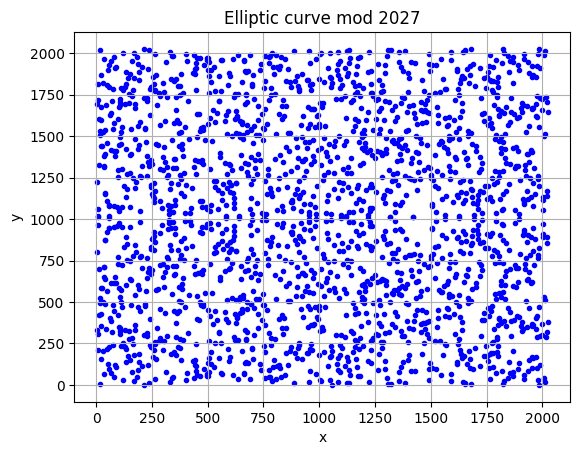

In [4]:
# Отобразим точки на кривой y^2 ≡ x^3 + 7 (mod {p}) на графике
plt.title(f"Elliptic curve mod {p}")
plt.scatter(points_x, points_y,  marker='.', color='blue')
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Базовые групповые операции в группе точек эллиптической кривой

In [5]:
# Сложение двух точек на кривой
def point_add(P: Optional[Tuple[int, int]], 
              Q: Optional[Tuple[int, int]]):
    if P is None:
        return Q
    if Q is None:
        return P

    x1, y1 = P
    x2, y2 = Q

    # P + (-P) = O
    if x1 == x2 and (y1 + y2) % p == 0:
        return None

    if P != Q:
        # λ = (y2 - y1) / (x2 - x1)
        num = (y2 - y1) % p
        den = (x2 - x1) % p
    else:
        # удвоение: λ = (3x1^2 + a) / (2y1)
        num = (3 * x1 * x1 + a) % p  # numerator числитель
        den = (2 * y1) % p           # denominator знаменатель

    # в трёхаргументном pow(a, b, p) отрицательная степень — это не обычное возведение в степень, 
    # Python интерпретирует это как модульную обратную:
    # a * x ≡ 1 (mod p)
    # т. о. обратный элемент к den по модулю p
    inv_den = pow(den, -1, p)

    lamda = (num * inv_den) % p  # коэффициента наклона прямой, который используется при сложении точек на эллиптической кривой

    # x3 = λ^2 − x1 − x2 (mod p)
    x3 = (lamda * lamda - x1 - x2) % p
    # y3 = λ(x1 − x3) − y1 (mod p)
    y3 = (lamda * (x1 - x3) - y1) % p

    return (x3, y3)

In [6]:
# Умножение точки на скаляр
# Это ключевая операция в ECC.
# Мы будем использовать алгоритм double-and-add (удвоение и добавление), потому что он быстрый и простой.
def scalar_mul(k: int, P):
    result = None  # это будет O
    addend = P     # текущая добавляемая точка

    while k > 0:
        if k & 1:  # если младший бит = 1
            result = point_add(result, addend)

        addend = point_add(addend, addend)  # удвоение
        k >>= 1  # сдвиг вправо (деление на 2)

    return result

In [7]:
# Проверка порядка точки
def point_order(P, logging = False):
    Q = P
    n = 1
    while Q is not None:
        curr_point = Q if Q is not None else P
        if logging:
            print(n, curr_point)
        Q = point_add(Q, P)
        n += 1
    if logging:
        print(n, f"{P} вернулись в изначальную точку G")
    return n

In [8]:
# Подгруппы точек
processed = set()   # точки, которые уже принадлежат найденным подгруппам
unique_groups = []  # список уникальных подгрупп (точка + порядок)

for x, y in zip(points_x, points_y):
    P = (x, y)

    # если точка уже в обработанной подгруппе — пропускаем
    if P in processed:
        continue

    # вычисляем порядок точки
    n = point_order(P)

    # добавляем подгруппу в processed
    subgroup = set()
    Q = None
    for k in range(n):
        Q = scalar_mul(k, P)
        if Q is not None:
            subgroup.add(Q)

    processed |= subgroup  # объединяем множества

    # сохраняем уникальную подгруппу
    unique_groups.append((P, n))


for P, n in unique_groups:
    print(P, "Порядок группы:", n)

(4, 334) Порядок группы: 507
(6, 803) Порядок группы: 676
(7, 212) Порядок группы: 1014
(8, 1010) Порядок группы: 2028


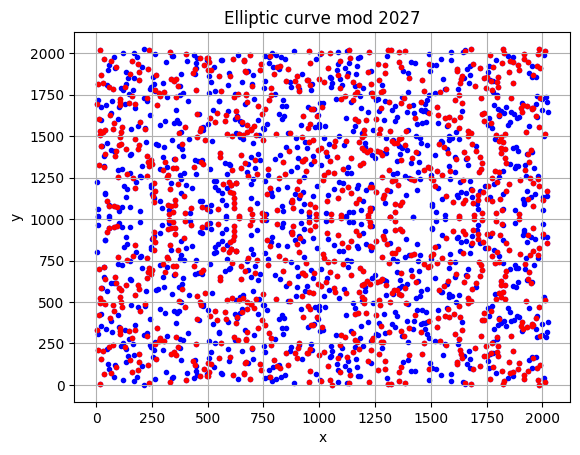

In [9]:
# Отметим на графике красным цветом точки принадлежащие группе G = (1, 5)
points_x2 = []
points_y2 = []

G = (7, 212)
Q = G
while Q is not None:
    x, y = Q
    points_x2.append(x) 
    points_y2.append(y)
    Q = point_add(Q, G)


plt.title(f"Elliptic curve mod {p}")
plt.scatter(points_x, points_y,  marker='.', color='blue')
plt.scatter(points_x2, points_y2,  marker='.', color='red')
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()